In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('tag1.csv')

In [4]:
df

,Unnamed: 0,content,keywords
0,12,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
1,13,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
2,15,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
3,40,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
4,41,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
...,...,...,...
752,966,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Prejudiciële bevoegheid (Grondwettelijk Hof)
753,967,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Prejudiciële bevoegheid (Grondwettelijk Hof)
754,972,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof)
755,977,"""Klagen auf vC6llige oder teilweise Nichtigerk...",Prejudiciële bevoegheid (Grondwettelijk Hof)


In [5]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rahi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
token = nltk.word_tokenize(df['content'][0])

In [7]:
token

['``',
 'La',
 'Cour',
 'constitutionnelle',
 ',',
 'composC',
 ')',
 'e',
 'des',
 'prC',
 ')',
 'sidents',
 'F.',
 'DaoC',
 ';',
 't',
 'et',
 'A.',
 'Alen',
 ',',
 'et',
 'des',
 'juges',
 'L.',
 'Lavrysen',
 ',',
 'J.-P.',
 'Snappe',
 ',',
 'J.-P.',
 'Moerman',
 ',',
 'E.',
 'Derycke',
 ',',
 'T.',
 'Merckx-Van',
 'Goey',
 ',',
 'P.',
 'Nihoul',
 ',',
 'T.',
 'Giet',
 ',',
 'R.',
 'Leysen',
 ',',
 'J.',
 'Moerman',
 'et',
 'M.',
 'PC\\',
 "''",
 'ques',
 ',',
 'assistC',
 ')',
 'e',
 'du',
 'greffier',
 'P.-Y',
 '.',
 'Dutilleux',
 ',',
 'prC',
 ')',
 'sidC',
 ')',
 'e',
 'par',
 'le',
 'prC',
 ')',
 'sident',
 'F.',
 'DaoC',
 ';',
 't',
 ',',
 'aprC',
 '(',
 's',
 'en',
 'avoir',
 'dC',
 ')',
 'libC',
 ')',
 'rC',
 ')',
 ',',
 'rend',
 "l'arrC",
 '*',
 't',
 'suivant',
 ':',
 'I.',
 'Objet',
 'du',
 'recours',
 'et',
 'procC',
 ')',
 'durePar',
 'requC',
 '*',
 'te',
 'adressC',
 ')',
 'e',
 'C',
 'la',
 'Cour',
 'par',
 'lettre',
 'recommandC',
 ')',
 'e',
 'C',
 'la',
 'poste',


In [8]:
# pip install langdetect

In [9]:
from langdetect import detect

In [10]:
df["language"] = df["content"].apply(detect)

print(df.sample(10))

     Unnamed: 0                                            content  \
321          86  "La Cour constitutionnelle,composC)e des prC)s...   
119         231  \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...   
395          94  \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...   
189         305  "Het Grondwettelijk Hof,samengesteld uit de vo...   
362         283  "La Cour constitutionnelle,composC)e des prC)s...   
214         546  "Het Grondwettelijk Hof,samengesteld uit de vo...   
394          91  \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...   
201         391  "La Cour constitutionnelle,composC)e des prC)s...   
64          300  "Het Grondwettelijk Hof,samengesteld uit de vo...   
138         104  "Het Grondwettelijk Hof,samengesteld uit de vo...   

                                          keywords language  
321   Prejudiciële bevoegheid (Grondwettelijk Hof)       fr  
119  Vernietigingsbevoegdheid (Grondwettelijk Hof)       nl  
395   Prejudiciële bevoegheid (Grondwetteli

In [11]:
df['language'].unique()

array(['fr', 'nl', 'de', 'bn'], dtype=object)

In [12]:
# uv pip install nltk spacy gensim transformers

In [13]:
# !python -m spacy download fr_core_news_sm
# !python -m spacy download de_core_news_sm
# !python -m spacy download nl_core_news_sm

In [14]:
import re

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'\d+', '', text)
    
    text = re.sub(r'[^\w\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['cleaned_content'] = df['content'].apply(clean_text)

In [15]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stopwords_all = set(stopwords.words('french') +
                    stopwords.words('german') +
                    stopwords.words('dutch'))

def remove_stopwords(text):
    
    words = text.split()
    
    filtered = [w for w in words if w not in stopwords_all]
    
    return " ".join(filtered)

df['cleaned_content'] = df['cleaned_content'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rahi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
df

,Unnamed: 0,content,keywords,language,cleaned_content
0,12,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),fr,cour constitutionnellecomposce prcsidents f da...
1,13,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),nl,grondwettelijk hofsamengesteld voorzitters f d...
2,15,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof),de,verfassungsgerichtshofzusammengesetzt prcsiden...
3,40,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),fr,cour constitutionnellecomposce prcsidents f da...
4,41,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),nl,grondwettelijk hofsamengesteld voorzitters f d...
...,...,...,...,...,...
752,966,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Prejudiciële bevoegheid (Grondwettelijk Hof),nl,grondwettelijk hofsamengesteld voorzitters spr...
753,967,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Prejudiciële bevoegheid (Grondwettelijk Hof),nl,grondwettelijk hofsamengesteld voorzitters e g...
754,972,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof),de,verfassungsgerichtshofzusammengesetzt prcsiden...
755,977,"""Klagen auf vC6llige oder teilweise Nichtigerk...",Prejudiciële bevoegheid (Grondwettelijk Hof),de,klagen vcllige teilweise nichtigerklcrung gese...


In [17]:
import spacy

nlp_fr = spacy.load("fr_core_news_sm")
nlp_de = spacy.load("de_core_news_sm")
nlp_nl = spacy.load("nl_core_news_sm")

In [18]:
def lemmatize_text(text, lang="fr"):
    
    if lang == "fr":
        doc = nlp_fr(text)
    elif lang == "de":
        doc = nlp_de(text)
    else:
        doc = nlp_nl(text)
    
    return " ".join([token.lemma_ for token in doc])

In [19]:
df['lemmatized_content'] = df.apply(lambda row: lemmatize_text(row['cleaned_content'], row['language']), axis=1)

In [29]:
uv pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


Using Python 3.13.4 environment at: C:\Users\rahi\Downloads\Bacancy\vpython
Resolved 12 packages in 2.23s
Prepared 1 package in 243ms
Installed 1 package in 129ms
 + wordcloud==1.9.6


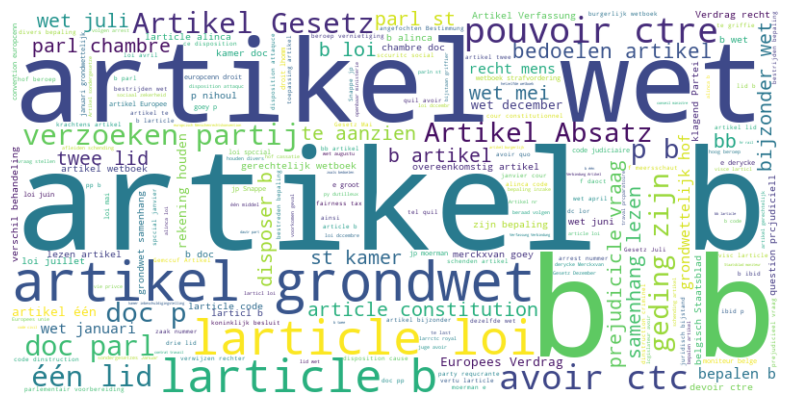

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=set(STOPWORDS)).generate(df['lemmatized_content'].str.cat(sep=' '))

# Display the generated image using matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [21]:
df['keywords'].unique()

array(['Vernietigingsbevoegdheid (Grondwettelijk Hof)',
       'Prejudiciële bevoegheid (Grondwettelijk Hof)'], dtype=object)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

def vectorize_text(text_data):
    
    vectorizer = TfidfVectorizer(max_features=5000)
    
    X = vectorizer.fit_transform(text_data)
    
    return X, vectorizer

X, vectorizer = vectorize_text(df['lemmatized_content'])

In [23]:
import pickle

# pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, df['keywords'], test_size=0.2, random_state=42)

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                                               precision    recall  f1-score   support

 Prejudiciële bevoegheid (Grondwettelijk Hof)       0.95      0.99      0.97        91
Vernietigingsbevoegdheid (Grondwettelijk Hof)       0.98      0.92      0.95        61

                                     accuracy                           0.96       152
                                    macro avg       0.96      0.95      0.96       152
                                 weighted avg       0.96      0.96      0.96       152



In [27]:
y_pred = model.predict(X_test[0])
y_pred

array(['Prejudiciële bevoegheid (Grondwettelijk Hof)'], dtype=object)